In [1]:
# 1. Import libraries
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import rasterio
import rioxarray
from rasterstats import zonal_stats
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling, calculate_default_transform
from rasterio.transform import Affine, from_origin
from rasterio.windows import from_bounds
import os

from scipy.stats import linregress

In [2]:
'''
Colockum Tarps - 2013 - ID: 33120
Carlton Complex - 2014 - ID: 199758
Canyon Creek Complex - 2015 - ID: 40024 
Godkin - 2016 - ID: NA
Riverside - 2020 - ID: 38454
Goddard Road - 2021 - ID: 79296
Bolt Creek - 2022 - ID: 32836
'''

'\nColockum Tarps - 2013 - ID: 33120\nCarlton Complex - 2014 - ID: 199758\nCanyon Creek Complex - 2015 - ID: 40024 \nGodkin - 2016 - ID: NA\nRiverside - 2020 - ID: 38454\nGoddard Road - 2021 - ID: 79296\nBolt Creek - 2022 - ID: 32836\n'

In [3]:
proj_dir = "/Users/dalo2903/Library/CloudStorage/OneDrive-UCB-O365/Documents/dev/intensity_x_severity/"
CASE_GPKG = proj_dir + "fire_perims_case_studies.gpkg"
VIIRS_GPKG = proj_dir + "westUS_FIRED_daily_viirs_gridstats_2012-2025_final.gpkg"

cbi_2013_5070_path = proj_dir + "2013_pnw_firedv2_bccbi_epsg5070.tif"
cbi_2014_5070_path = proj_dir + "2014_pnw_firedv2_bccbi_epsg5070.tif"
cbi_2015_5070_path = proj_dir + "2015_pnw_firedv2_bccbi_epsg5070.tif"
cbi_2016_5070_path = proj_dir + "2016_pnw_firedv2_bccbi_epsg5070.tif"
cbi_2020_5070_path = proj_dir + "2020_pnw_firedv2_bccbi_epsg5070.tif"
cbi_2021_5070_path = proj_dir + "2021_pnw_firedv2_bccbi_epsg5070.tif"
cbi_2022_5070_path = proj_dir + "2022_pnw_firedv2_bccbi_epsg5070.tif"

forest_mask_2013 = proj_dir + 'forest_masks_2013.tif'

viirs = gpd.read_file(VIIRS_GPKG)

In [4]:
viirs_singlefire = viirs.loc[viirs["id"] == 33120].copy() 
annual_cbi = cbi_2013_5070_path

In [5]:
# Rasterize at native 375 m

pixel_size = 375

minx, miny, maxx, maxy = viirs_singlefire.total_bounds

width = int((maxx - minx) / pixel_size)
height = int((maxy - miny) / pixel_size)

transform_375 = from_origin(minx, maxy, pixel_size, pixel_size)

shapes = (
    (geom, value)
    for geom, value in zip(
        viirs_singlefire.geometry,
        viirs_singlefire["frp_norm_csum"]
    )
)

viirs_375 = rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=transform_375,
    fill=np.nan,
    dtype="float32"
)

# Now resample with nearest neighbor
target_res = 30

width_30 = int((maxx - minx) / target_res)
height_30 = int((maxy - miny) / target_res)

transform_30 = from_origin(minx, maxy, target_res, target_res)

viirs_30_nn = np.empty((height_30, width_30), dtype="float32")
viirs_30_bil = np.empty((height_30, width_30), dtype="float32")


reproject(
    source=viirs_375,
    destination=viirs_30_nn,
    src_transform=transform_375,
    src_crs="EPSG:5070",
    dst_transform=transform_30,
    dst_crs="EPSG:5070",
    resampling=Resampling.nearest,
    src_nodata=np.nan,
    dst_nodata=np.nan
)
reproject(
    source=viirs_375,
    destination=viirs_30_bil,
    src_transform=transform_375,
    src_crs="EPSG:5070",
    dst_transform=transform_30,
    dst_crs="EPSG:5070",
    resampling=Resampling.bilinear,
    src_nodata=np.nan,
    dst_nodata=np.nan
)

(array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], dtype=float32),
 Affine(30.0, 0.0, -1830598.8931489633,
        0.0, -30.0, 2938956.9144750987))

In [9]:
out_path = "viirs_cfrp_30m_resampled.tif"
height, width = viirs_30_nn.shape
'''
with rasterio.open(
    out_path,
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=2,                # TWO bands
    dtype=viirs_30_nn.dtype,
    crs=viirs_crs,
    transform=transform_30,
    nodata=np.nan
) as dst:

    dst.write(viirs_30_nn, 1)   # Band 1
    dst.write(viirs_30_bil, 2)  # Band 2

    dst.set_band_description(1, "cFRP_nearest_neighbor")
    dst.set_band_description(2, "cFRP_bilinear")

print("✅ Saved multiband VIIRS cFRP raster")
'''
with rasterio.open(out_path) as src:
    nn = src.read(1, masked=True)
    bil = src.read(2, masked=True)
    bounds = src.bounds
    viirs_transform = src.transform
    viirs_crs = src.crs

stats = {
    "nn_mean": nn.mean(),
    "nn_median": np.ma.median(nn),
    "bil_mean": bil.mean(),
    "bil_median": np.ma.median(bil),
}
# Log-transform cFRP for visualization
log_nn = np.ma.log(nn + 1)
log_bil = np.ma.log(bil + 1)

In [10]:
with rasterio.open(annual_cbi) as csrc:
    print(csrc.crs)
    assert csrc.crs == viirs_crs, "CRS mismatch!"

    window = from_bounds(*bounds, transform=csrc.transform)
    cbi_crop = csrc.read(1,window=window)
    cbi_transform = csrc.window_transform(window)

with rasterio.open(forest_mask_2013) as fsrc:
    forest_crop = fsrc.read(1, window=window, masked=True) # layer 2 is conservative forest extenet
    cbi_no_forest = np.ma.masked_where(
        forest_crop == 1,
        cbi_crop)
    cbi_forest_only = np.ma.masked_where(
        forest_crop == 0,
        cbi_crop)
 
    # --- Calculate % forest inside fire perimeter ---
    valid_fire_pixels = np.isfinite(cbi_crop)
    forest_pixels = (forest_crop == 1) & valid_fire_pixels
    total_fire_pixels = valid_fire_pixels.sum()
    total_forest_pixels = forest_pixels.sum()
    percent_forest = (total_forest_pixels / total_fire_pixels) * 100

    print(f"Forest pixels: {total_forest_pixels:,}")
    print(f"Total fire pixels: {total_fire_pixels:,}")
    print(f"Percent of fire perimeter that is forest: {percent_forest:.2f}%")

EPSG:5070
Forest pixels: 4,734
Total fire pixels: 302,239
Percent of fire perimeter that is forest: 1.57%


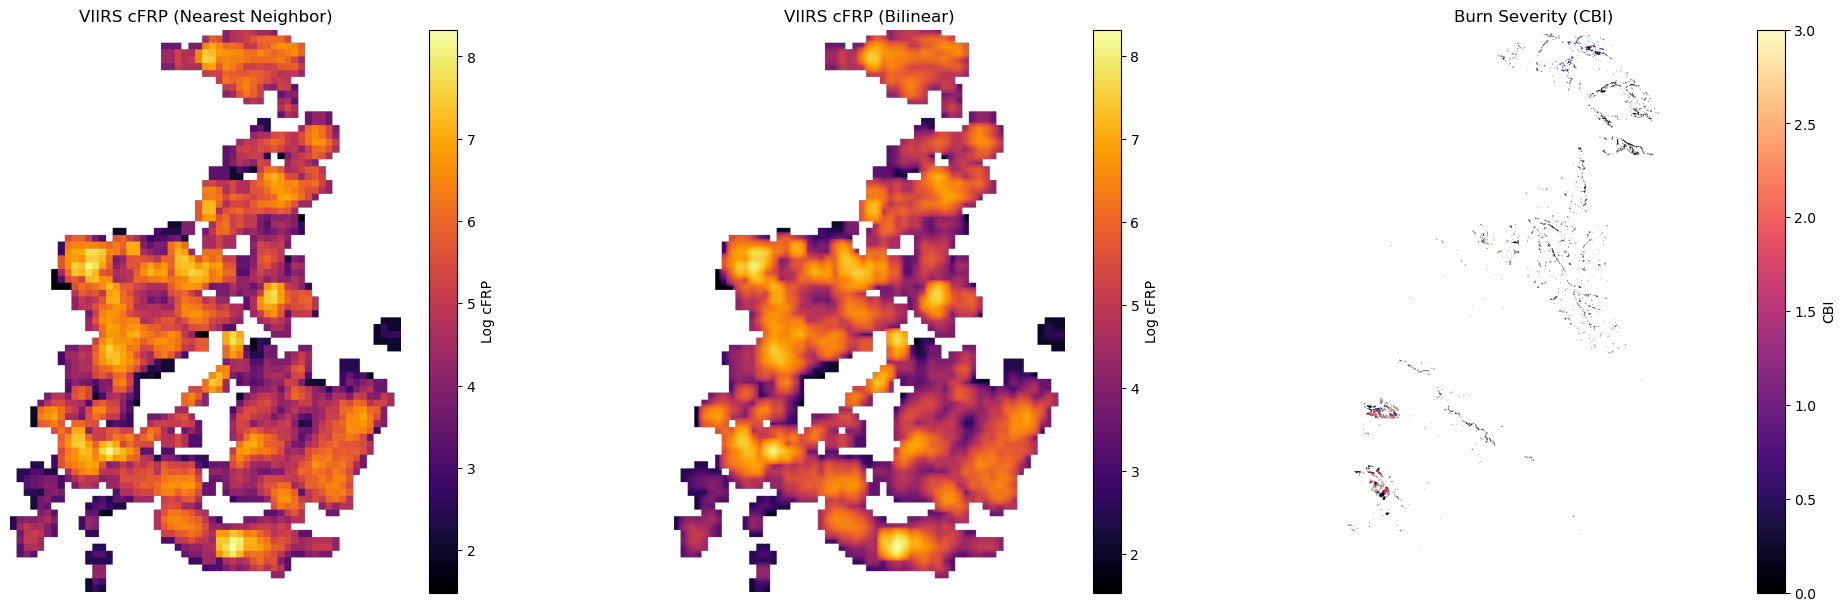

In [11]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(20, 6),
    constrained_layout=True
)

# -------------------------------
# Plot 1: VIIRS cFRP (Nearest Neighbor)
# -------------------------------
im0 = axes[0].imshow(log_nn, cmap="inferno")
plt.colorbar(im0, ax=axes[0], label="Log cFRP")
axes[0].set_title("VIIRS cFRP (Nearest Neighbor)")
axes[0].axis("off")

# -------------------------------
# Plot 2: VIIRS cFRP (Bilinear)
# -------------------------------
im1 = axes[1].imshow(log_bil, cmap="inferno")
plt.colorbar(im1, ax=axes[1], label="Log cFRP")
axes[1].set_title("VIIRS cFRP (Bilinear)")
axes[1].axis("off")

# -------------------------------
# Plot 3: CBI
# -------------------------------
im2 = axes[2].imshow(cbi_forest_only, cmap="magma", vmin=0, vmax=3)
plt.colorbar(im2, ax=axes[2], label="CBI")
axes[2].set_title("Burn Severity (CBI)")
axes[2].axis("off")

plt.show()


In [12]:
def heatmap_regression(df, ax, title):
    # 1. Prepare data
    df_clean = df[["log_frp", "cbi"]].dropna()
    x = df_clean["log_frp"].values
    y = df_clean["cbi"].values

    # 2. Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = intercept + slope * x_fit

    # 3. Create Heatmap (2D Histogram)
    # cbar=True adds the density scale; bins controls the resolution
    sns.histplot(
        data=df_clean, x="log_frp", y="cbi", 
        bins=300, pthresh=.1, cmap="viridis", 
        vmin = 0, vmax = 100,
        cbar=True, ax=ax, cbar_kws={'label': 'Point Density'}
        
    )

    # 4. Overlay Regression Line
    ax.plot(x_fit, y_fit, color="red", linewidth=2.5, label="Regression")

    # 5. Formatting
    ax.set_xlabel("log(VIIRS cFRP)")
    ax.set_ylabel("CBI")
    ax.set_title(title)
    ax.text(
        0.05, 0.95,
        f"$R^2$ = {r_value**2:.2f}\n"
        f"slope = {slope:.2f}\n"
        f"p = {p_value:.2e}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
    )
    ax.grid(True, linewidth=0.3, alpha=0.5)

In [13]:
# Flatten arrays
'''
cbi_vals = cbi_forest_only.flatten()
nn_vals = log_nn.flatten()
bil_vals = log_bil.flatten()
'''
cbi_vals = cbi_forest_only.filled(np.nan).flatten() #WAS cbi_forest_only
nn_vals = np.array(log_nn).flatten()
bil_vals = np.array(log_bil).flatten()

# Build masks
mask_nn = (
    np.isfinite(cbi_vals) &
    np.isfinite(nn_vals)
)

mask_bil = (
    np.isfinite(cbi_vals) &
    np.isfinite(bil_vals)
)

# DataFrames
df_nn = pd.DataFrame({
    "cbi": cbi_vals[mask_nn],
    "log_frp": nn_vals[mask_nn]
})

df_bil = pd.DataFrame({
    "cbi": cbi_vals[mask_bil],
    "log_frp": bil_vals[mask_bil]
})


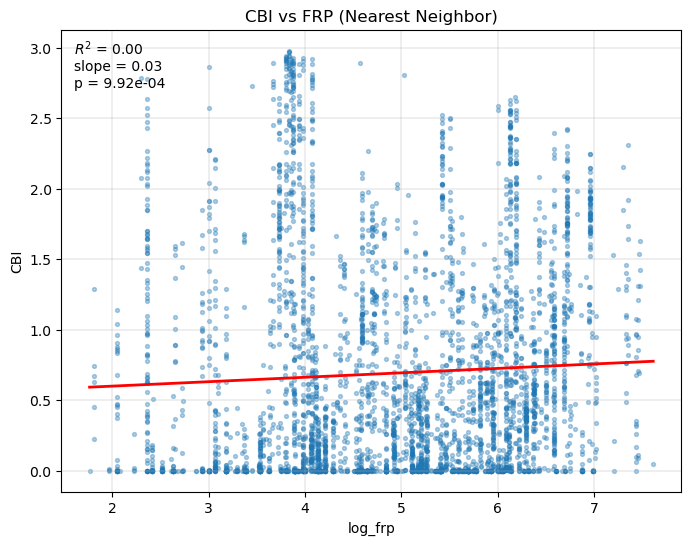

In [14]:
# Choose predictor column
x_pred = "log_frp"   # change if needed

# Extract values
x = df_nn[x_pred].values
y = df_nn["cbi"].values

# Remove NaN / infinite values (important for slope/R2 not being NaN)
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Fit line
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = intercept + slope * x_fit

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(x, y, alpha=0.35, s=8)
ax.plot(x_fit, y_fit, color="red", linewidth=2)

ax.set_xlabel(x_pred)
ax.set_ylabel("CBI")
ax.set_title("CBI vs FRP (Nearest Neighbor)")

ax.text(
    0.02, 0.98,
    f"$R^2$ = {r_value**2:.2f}\n"
    f"slope = {slope:.2f}\n"
    f"p = {p_value:.2e}",
    transform=ax.transAxes,
    verticalalignment="top"
)

ax.grid(True, linewidth=0.3)

plt.show()


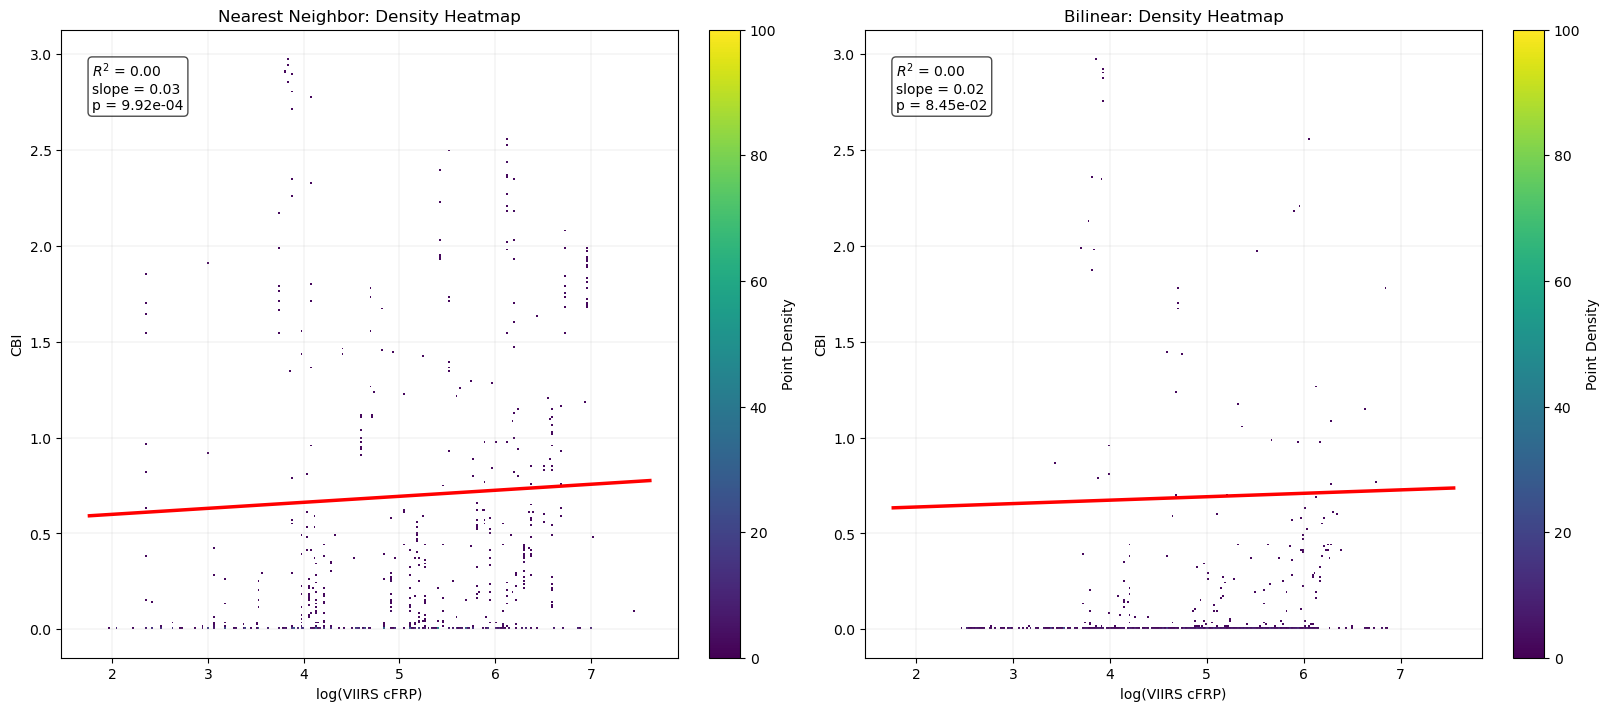

In [15]:
# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

heatmap_regression(df_nn, axes[0], "Nearest Neighbor: Density Heatmap")
heatmap_regression(df_bil, axes[1], "Bilinear: Density Heatmap")

plt.show()

Index(['grid_index', 'id', 'assigned_did', 'overlap_area', 'overlap_fraction',
       'assignment_method', 'afd_count', 'frp_norm_csum', 'frp_norm_max',
       'frp_norm_min', 'frp_norm_p90', 'frp_norm_p95', 'frp_norm_p99',
       'unique_days', 'first_obs_date', 'last_obs_date', 'frp_norm_count_d',
       'frp_norm_count_n', 'frp_norm_sum_d', 'frp_norm_sum_n',
       'frp_norm_max_d', 'frp_norm_max_n', 'obs_duration', 'geometry'],
      dtype='object')


(array([1.957e+03, 7.700e+01, 9.000e+00, 3.100e+01, 2.400e+01, 2.200e+01,
        1.300e+01, 0.000e+00, 1.000e+00, 4.000e+00]),
 array([ 0. ,  1.8,  3.6,  5.4,  7.2,  9. , 10.8, 12.6, 14.4, 16.2, 18. ]),
 <BarContainer object of 10 artists>)

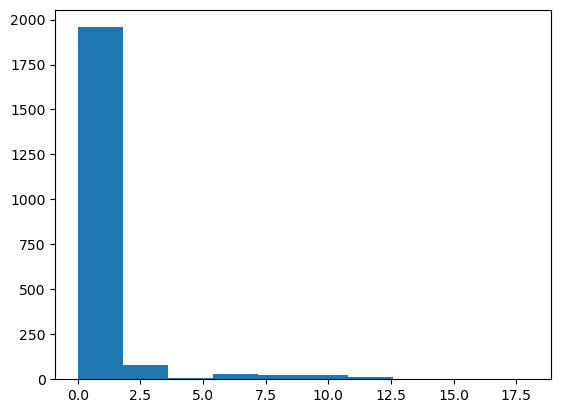

In [16]:
print(viirs_singlefire.columns)
plt.hist(viirs_singlefire['obs_duration'])

In [17]:
# Compute summary statistics on cFRP
stats = {
    "mean_cfrp": viirs_singlefire["frp_norm_csum"].mean(),
    "median_cfrp": viirs_singlefire["frp_norm_csum"].median(),
    "min_cfrp": viirs_singlefire["frp_norm_csum"].min(),
    "max_cfrp": viirs_singlefire["frp_norm_csum"].max(),
    "n_cells": len(viirs_singlefire)
}

print("\n=== Riverside Fire — VIIRS cFRP (within perimeter) ===")
for k, v in stats.items():
    print(f"{k}: {v:.2f}" if isinstance(v, float) else f"{k}: {v}")



=== Riverside Fire — VIIRS cFRP (within perimeter) ===
mean_cfrp: 314.23
median_cfrp: 164.24
min_cfrp: 3.41
max_cfrp: 4124.90
n_cells: 2138


In [18]:
# Define duration categories
def duration_category(d):
    if d < 1:
        return "0-1 days"
    elif d <= 2:
        return "1-2 days"
    #elif d <= 9:
        #return "3-9 days"
    else:
        return "3+ days"

In [19]:
# Compute zonal stats (mean burn severity inside each polygon)

# Convert masked array to real NaNs
cbi_array = cbi_forest_only.filled(np.nan) #WAS cbi_forest_only

downsample_stats = zonal_stats(
    viirs_singlefire,
    cbi_array,
    affine=cbi_transform,   # VERY IMPORTANT
    stats=["mean", "median", "min", "max", "percentile_95", "std"],
    nodata=np.nan,
    all_touched=True
)

# Add results to GeoDataFrame
viirs_singlefire['cbi_mean'] = [s['mean'] for s in downsample_stats]
viirs_singlefire['cbi_stdev'] = [s['std'] for s in downsample_stats]
viirs_singlefire['cbi_median'] = [s['median'] for s in downsample_stats]
viirs_singlefire['cbi_min'] = [s['min'] for s in downsample_stats]
viirs_singlefire['cbi_max'] = [s['max'] for s in downsample_stats]
viirs_singlefire['cbi_95'] = [s['percentile_95'] for s in downsample_stats]

In [20]:
viirs_singlefire['log_cfrp'] = np.log(viirs_singlefire["frp_norm_csum"] + 1)
# Apply duration grouping
viirs_singlefire["duration_group"] = viirs_singlefire["obs_duration"].apply(duration_category)
viirs_singlefire[["cbi_min", "cbi_median", "cbi_stdev", "cbi_mean", "cbi_max", "frp_norm_csum", "log_cfrp", "obs_duration"]].describe()

,cbi_min,cbi_median,cbi_stdev,cbi_mean,cbi_max,frp_norm_csum,log_cfrp,obs_duration
count,427.000000,427.000000,427.000000,427.000000,427.000000,2138.000000,2138.000000,2138.000000
mean,0.266313,0.504970,0.182318,0.516986,0.816544,314.230577,5.028744,0.617399
std,0.479058,0.615503,0.219949,0.589985,0.801297,406.759372,1.312648,1.928414
min,0.000000,0.000000,0.000000,0.000000,0.000000,3.413866,1.484751,0.000000
25%,0.000000,0.004758,0.000000,0.039231,0.138886,63.139330,4.161058,0.000000
50%,0.009540,0.269623,0.105552,0.287008,0.576469,164.238539,5.107390,0.000000
75%,0.356120,0.828785,0.301118,0.840818,1.271696,411.684876,6.022684,0.000000
max,2.888020,2.888020,1.360649,2.888020,2.979219,4124.897446,8.325039,18.000000


In [288]:
colockum_tarps = viirs_singlefire

In [57]:
bolt_creek = viirs_singlefire

In [137]:
carlton = viirs_singlefire

In [199]:
canyon_creek = viirs_singlefire

In [217]:
riverside = viirs_singlefire

In [266]:
goddard_rd = viirs_singlefire

In [21]:
import pandas as pd

# Put dataframes in the SAME order as fire names
dfs = [
    bolt_creek,
    canyon_creek,
    carlton,
    colockum_tarps,
    goddard_rd,
    riverside
]

fire_names = [
    "Bolt Creek",
    "Canyon Creek Complex",
    "Carlton Complex",
    "Colockum Tarps",
    "Goddard Road",
    "Riverside"
]

# Add fire name column to each dataframe
dfs_with_names = []
for df, name in zip(dfs, fire_names):
    df_copy = df.copy()
    df_copy["fire_name"] = name
    dfs_with_names.append(df_copy)

# Concatenate into one dataframe
all_fires_df = pd.concat(dfs_with_names, ignore_index=True)

# Save to CSV
all_fires_df.to_csv(proj_dir + "case_studies_combined.csv", index=False)

print("✅ Combined dataframe saved as case_studies_combined.csv")
all_fires_df.head()


NameError: name 'bolt_creek' is not defined

NameError: name 'dfs' is not defined

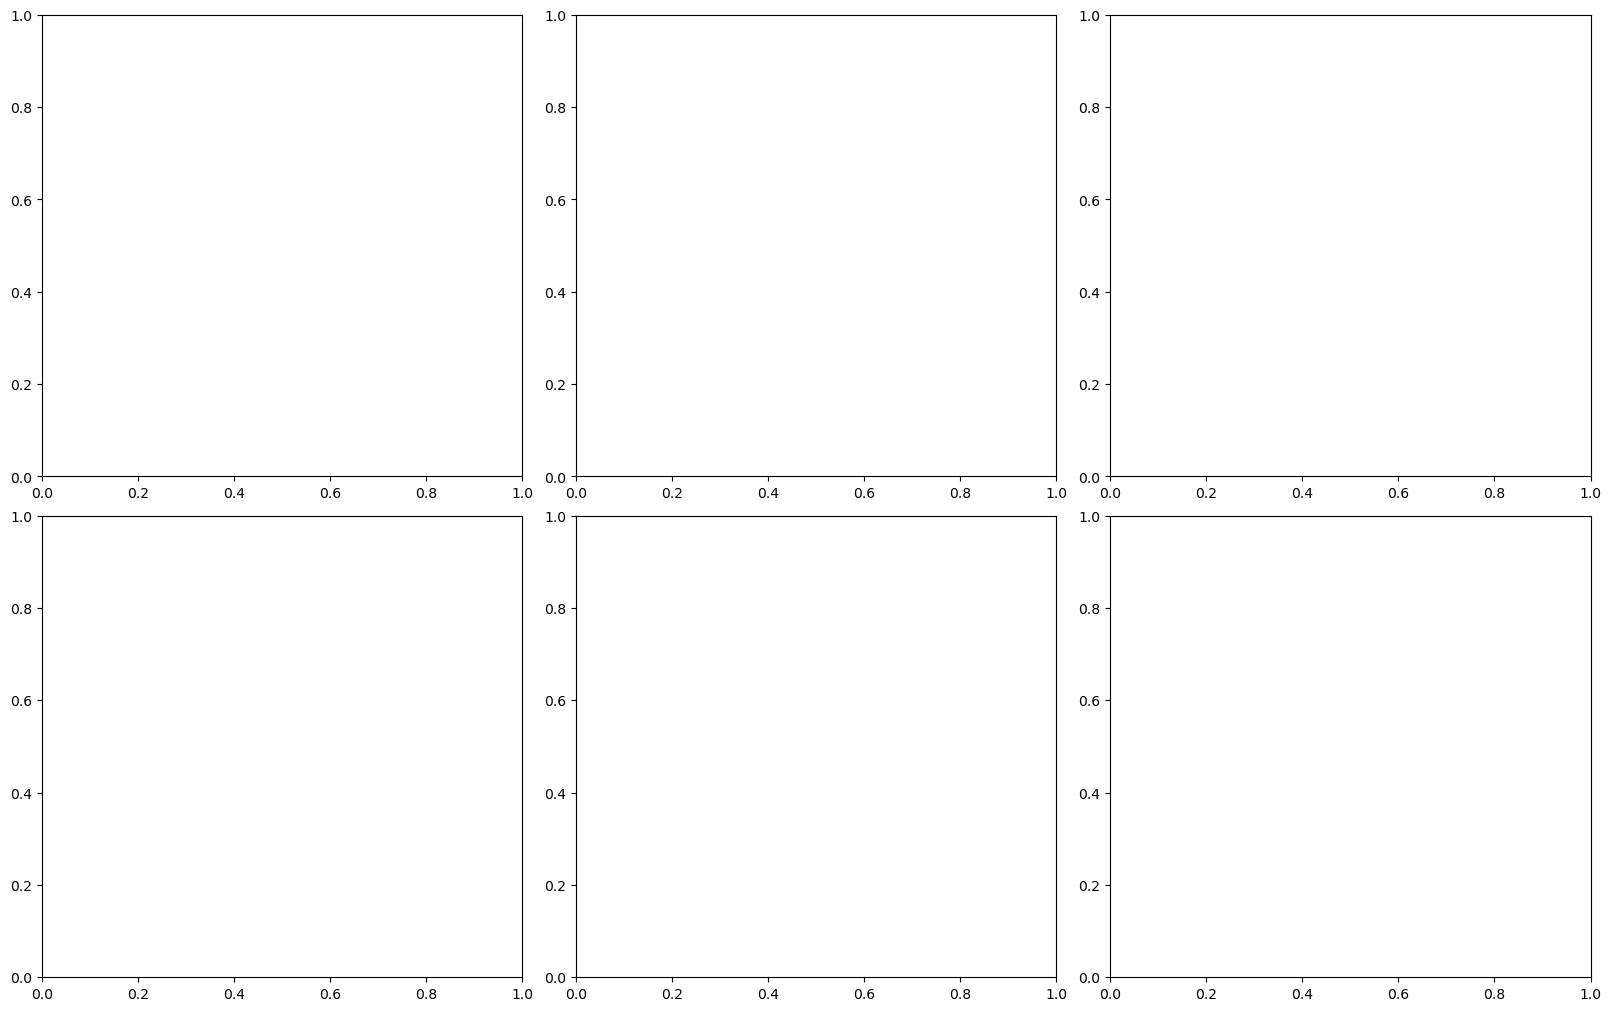

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
axes = axes.flatten()

for ax, df, fire_name in zip(axes, dfs, fire_names):

    # Extract data
    x = df["log_cfrp"].values
    y = df["cbi_mean"].values

    # Remove NaNs / inf
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    # Scatter
    ax.scatter(x, y, alpha=0.4, s=10)

    # Regression
    if len(x) > 2:
        slope, intercept, r_value, p_value, std_err = linregress(x, y)

        x_fit = np.linspace(0, 8, 100)
        y_fit = intercept + slope * x_fit

        ax.plot(x_fit, y_fit, linewidth=2)

        ax.text(
            0.05, 0.95,
            f"$R^2$ = {r_value**2:.2f}",
            transform=ax.transAxes,
            verticalalignment="top"
        )

    # Standardized axes
    ax.set_xlim(0, 9.5)
    ax.set_ylim(-0.2, 3.1)

    # Remove individual labels
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_title(fire_name)
    ax.grid(True, linewidth=0.3)

# Shared axis labels
fig.supxlabel("log(cFRP)", fontsize=14)
fig.supylabel("Mean CBI", fontsize=14)

plt.show()


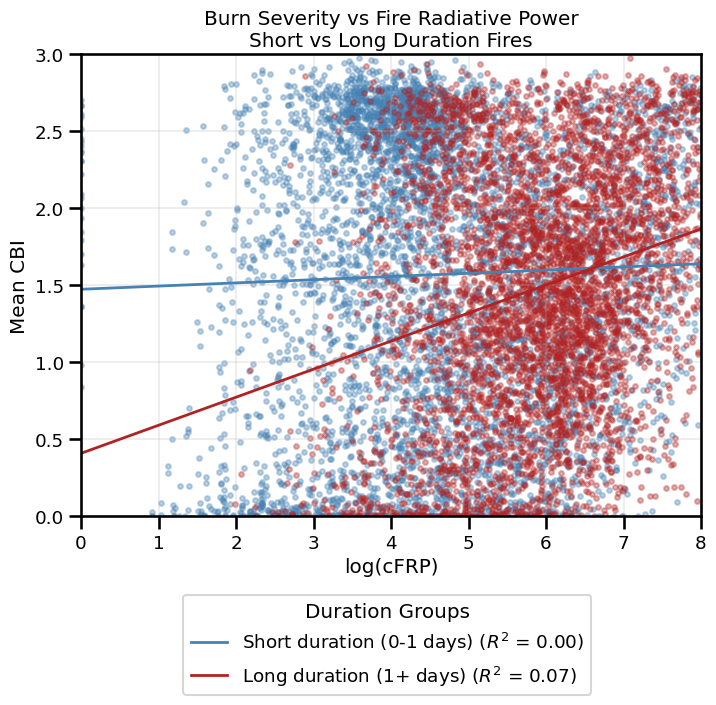

In [310]:
# Define short vs long duration groups
groups = {
    "Short duration (0-1 days)": all_fires_df[all_fires_df["duration_group"] == "0-1 days"],
    "Long duration (1+ days)": all_fires_df[all_fires_df["duration_group"].isin(["1-2 days", "3+ days"])]
}

colors = {
    "Short duration (0-1 days)": "steelblue",
    "Long duration (1+ days)": "firebrick"
}

fig, ax = plt.subplots(figsize=(8, 6))
x_fit = np.linspace(0, 8, 100)

legend_labels = []

for label, df_group in groups.items():
    x = df_group["log_cfrp"].values
    y = df_group["cbi_mean"].values

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    slope, intercept, r_value, p_value, _ = linregress(x, y)
    y_fit = intercept + slope * x_fit

    # scatter (no label)
    ax.scatter(x, y, alpha=0.35, s=12, color=colors[label])

    # line (label used for legend)
    ax.plot(
        x_fit,
        y_fit,
        color=colors[label],
        linewidth=2,
        label=f"{label} ($R^2$ = {r_value**2:.2f})"
    )

ax.set_xlim(0, 8)
ax.set_ylim(0, 3)
ax.set_xlabel("log(cFRP)")
ax.set_ylabel("Mean CBI")
ax.set_title("Burn Severity vs Fire Radiative Power\nShort vs Long Duration Fires")

# Create legend with R² values
ax.legend(title="Duration Groups", loc="upper left", bbox_to_anchor=(0.15, -0.15))
ax.grid(True, linewidth=0.3)

plt.show()

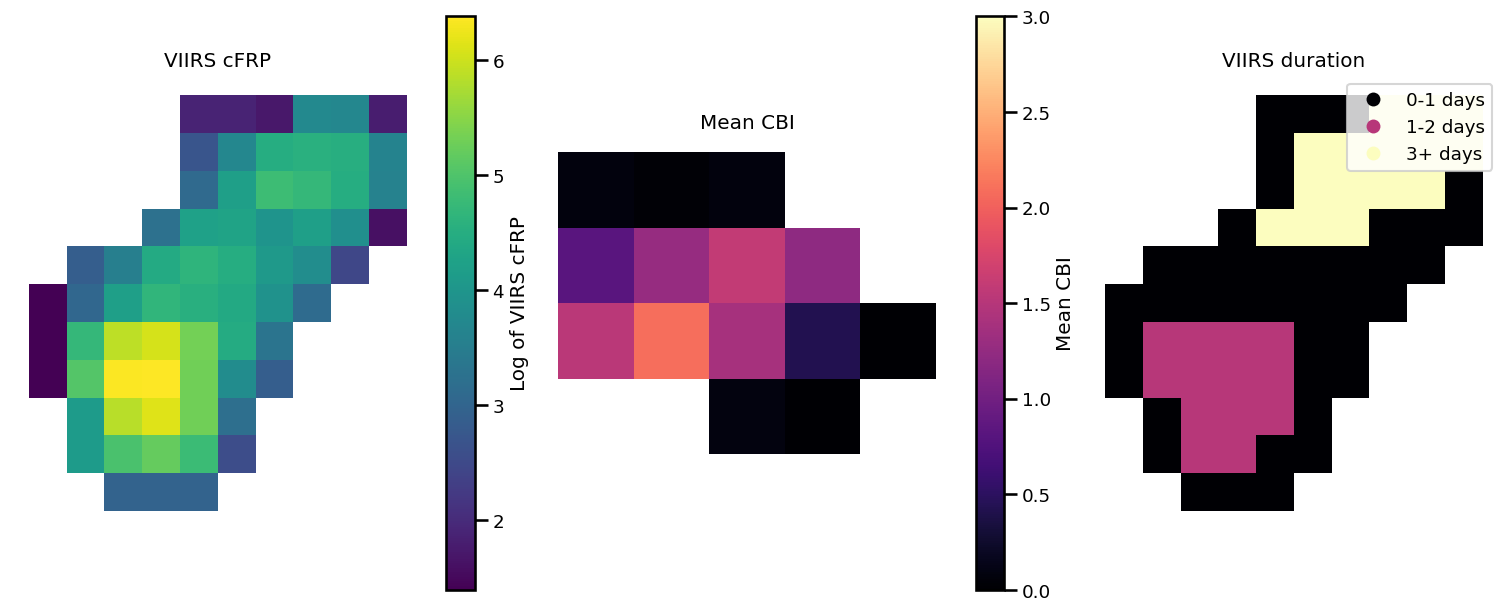

In [265]:
import matplotlib.pyplot as plt

# Set up figure
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 6),
    constrained_layout=True
)

# -------------------------------
# Plot 1: Mean VIIRS cFRP
# -------------------------------
viirs_singlefire.plot(
    column="log_cfrp",
    ax=axes[0],
    cmap="viridis",
    legend=True,
    legend_kwds={"label": "Log of VIIRS cFRP"},
    linewidth=0,
    #vmin=0,
    #vmax=3000,  # CBI range
)

axes[0].set_title("VIIRS cFRP")
axes[0].set_axis_off()


# -------------------------------
# Plot 2: Mean CBI
# -------------------------------
viirs_singlefire.plot(
    column="cbi_mean",
    ax=axes[1],
    cmap="magma",
    legend=True,
    legend_kwds={"label": "Mean CBI"},
    vmin=0,
    vmax=3,  # CBI range
    linewidth=0,
)

axes[1].set_title("Mean CBI")
axes[1].set_axis_off()


# -------------------------------
# Plot 3: Duration
# -------------------------------
viirs_singlefire.plot(
    column="duration_group",
    ax=axes[2],
    cmap="magma",
    legend=True,
    #legend_kwds={"label": "Duration"},
    linewidth=0,
    #vmin=0,
    #vmax=3000,  # CBI range
)

axes[2].set_title("VIIRS duration")
axes[2].set_axis_off()

plt.show()


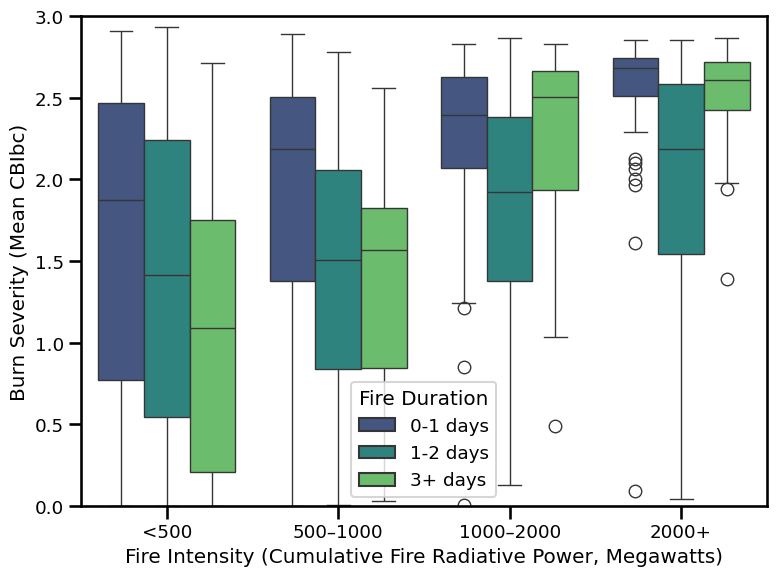

In [216]:
# Define intensity classes
bins = [0, 500, 1000, 2000, viirs_singlefire["frp_norm_csum"].max()]
#labels = ["<500", "500–1000", "1000–2000", "2000-5000","5000+"]
labels = ["<500", "500–1000", "1000–2000", "2000+"]
viirs_singlefire["intensity_class"] = pd.cut(viirs_singlefire["frp_norm_csum"], bins=bins, labels=labels, include_lowest=True)

# Drop NaNs
gdf_clean = viirs_singlefire.dropna(subset=["cbi_mean", "frp_norm_csum", "duration_group"])

# Boxplot
plt.figure(figsize=(8,6))
sns.set_context("talk", font_scale=0.8)  # roughly 16pt fonts

sns.boxplot(
    data=gdf_clean,
    x="intensity_class",
    y="cbi_mean",
    hue="duration_group",
    palette="viridis"
)

plt.ylim(0, 3)
plt.xlabel("Fire Intensity (Cumulative Fire Radiative Power, Megawatts)")
plt.ylabel("Burn Severity (Mean CBIbc)")
#plt.title("Burn Severity by Fire Intensity and Duration")
plt.legend(title="Fire Duration")
plt.tight_layout()
plt.show()


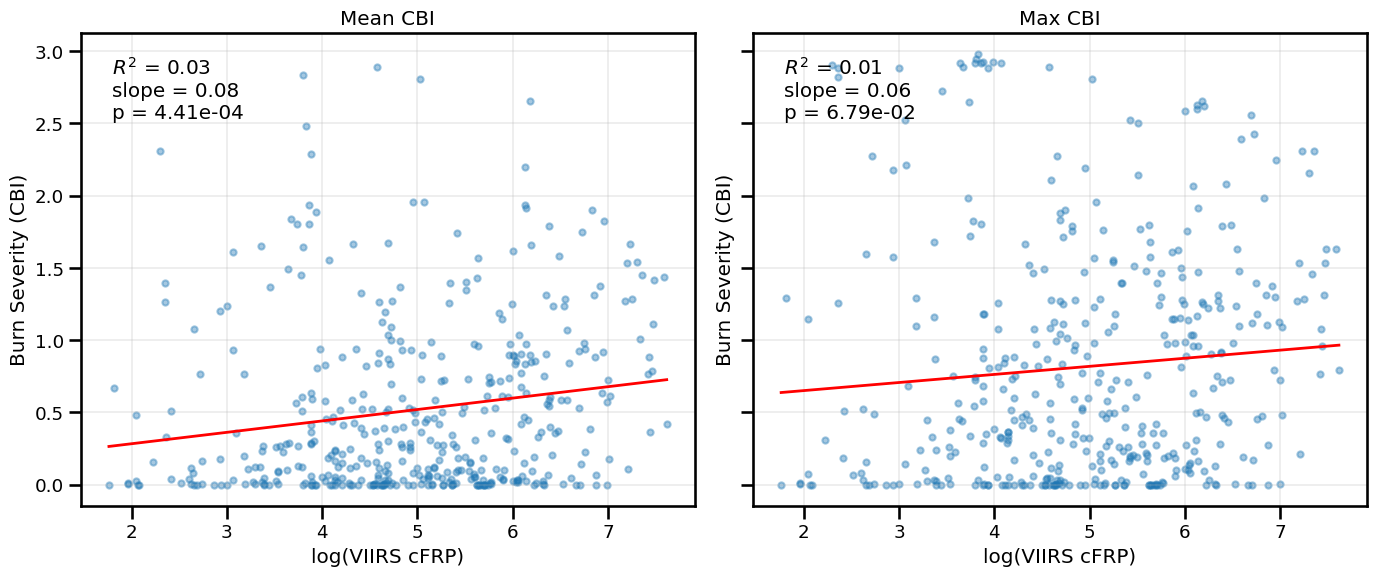

In [287]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

def plot_regression(fire_df, ax, x_col, y_col, title):
    # Drop NaNs for the specific pair
    df_plot = fire_df[[x_col, y_col]].dropna()
    x, y = df_plot[x_col].values, df_plot[y_col].values
    
    
    # Linear regression
    slope, intercept, r_val, p_val, std_err = linregress(x, y)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = intercept + slope * x_fit
    
    # Plotting
    ax.scatter(x, y, alpha=0.4, s=20)
    ax.plot(x_fit, y_fit, linewidth=2, color='red')
    ax.set_title(title)
    ax.set_xlabel("log(VIIRS cFRP)")
    ax.set_ylabel("Burn Severity (CBI)")
    
    # Add stats text
    stats_text = f"$R^2$ = {r_val**2:.2f}\nslope = {slope:.2f}\np = {p_val:.2e}"
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, verticalalignment="top")
    ax.grid(True, linewidth=0.3)

# Generate the two plots
plot_regression(viirs_singlefire, ax1, "log_cfrp", "cbi_mean", "Mean CBI")
plot_regression(viirs_singlefire, ax2, "log_cfrp", "cbi_max", "Max CBI")

plt.tight_layout()
plt.show()

In [61]:
cbi_orig_30m_path = proj_dir + "merged_pnw_firedv2_bccbi.tif"   
years = [2013, 2014, 2015, 2016, 2020, 2021, 2022]
target_crs = "EPSG:5070"
target_res = 30  # meters

with rasterio.open(cbi_orig_30m_path) as src:

    # Build year → band index lookup
    band_lookup = {
        int(name.split("_")[1]): i
        for i, name in enumerate(src.descriptions, start=1)
        if name and name.startswith("year_")
    }

    for year in years:
        print(f"\nProcessing {year}...")

        if year not in band_lookup:
            print(f"⚠️ Year {year} not found.")
            continue

        band_index = band_lookup[year]

        # Read band into memory
        cbi_data = src.read(band_index)

        # Compute new transform for EPSG:5070
        transform, width, height = calculate_default_transform(
            src.crs,
            target_crs,
            src.width,
            src.height,
            *src.bounds,
            resolution=target_res
        )

        # Update metadata for output
        meta = src.meta.copy()
        meta.update({
            "count": 1,
            "crs": target_crs,
            "transform": transform,
            "width": width,
            "height": height,
            "nodata": src.nodata
        })

        dst_path = os.path.join(
            proj_dir,
            f"{year}_pnw_firedv2_bccbi_epsg5070.tif"
        )

        # Create destination raster and reproject directly
        with rasterio.open(dst_path, "w", **meta) as dst:
            reproject(
                source=cbi_data,
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=target_crs,
                resampling=Resampling.bilinear,  # appropriate for ordinal CBI
                src_nodata=src.nodata,
                dst_nodata=src.nodata
            )

            dst.set_band_description(1, f"CBI_{year}")

        print(f"  ✅ Saved {year} reprojected to EPSG:5070")



Processing 2013...


KeyboardInterrupt: 